# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [ ]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
print(sys.executable)


c:\Users\samue\anaconda3\envs\sbck_env\python.exe


In [ ]:
import importlib
import functions
importlib.reload(functions)

from functions import (  # noqa: E402
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions_univ,
    comparer_distributions,
    cdf_t_univ_norm,
    plot_distributions_univ_norm
)

ModuleNotFoundError: No module named 'sbck'

## Implémentation CDF-t univariée (température)

### Correction CMIP6 sur les observations

On corrige pour chaque mois. On compare les distributions en représentant graphiquement les densités et en réalisant quelques statistiques descriptives.

In [ ]:
mois_a_afficher = [6, 12]  

for i in range (1,13): #on itère sur tous les mois

    #Sélection mois et variable
    CMIP6_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_historical.csv", i, "tas")
    CMIP6_futur = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_ssp585.csv", i, "tas")
    obs_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/obs.csv", i, "tas")

    #Correction des valeurs futures du modèle par CDF-t
    resultat = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur)

    #Représentation graphique
    if i in mois_a_afficher:
        plot_distributions_univ(resultat,"CMIP6", i, "tas")
        print(comparer_distributions(resultat))

On vérifie en utilisant comme estimations futures les estimations passées pour reconstruire les observations passées.

<Figure size 1200x600 with 0 Axes>

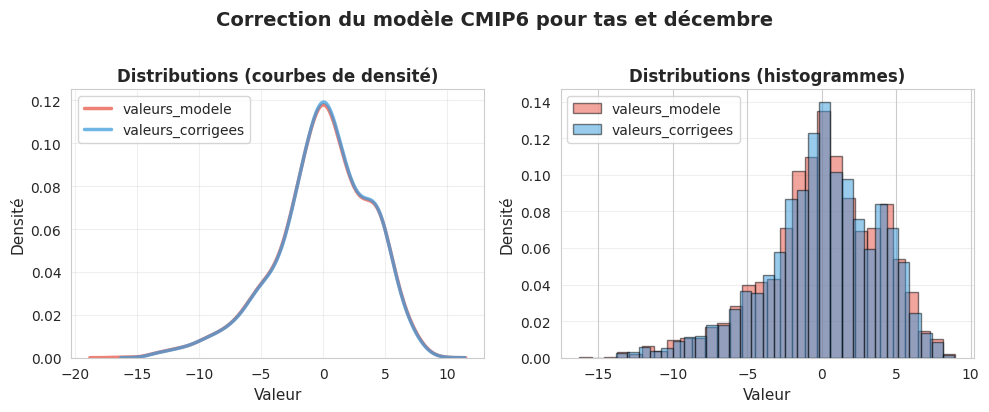

  Statistique  valeurs_modele  valeurs_corrigees
0     Moyenne          -0.028             -0.006
1     Médiane           0.175              0.167
2  Écart-type           3.878              3.836
3    Variance          15.040             14.714
4     Minimum         -16.273            -13.801
5     Maximum           8.956              8.905
6    Q1 (25%)          -2.067             -2.015
7    Q3 (75%)           2.734              2.741
8     Étendue          25.229             22.705


In [ ]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_historical.csv", 12, "tas")
CMIP6_futur = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_historical.csv", 12, "tas")
obs_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/obs.csv", i, "tas")

#Correction des valeurs futures du modèle par CDF-t
resultat = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur)

#Représentation graphique
plot_distributions_univ(resultat,"CMIP6", 12, "tas")
print(comparer_distributions(resultat))

On corrige cette fois dans le cas gaussien. On suppose que les distributions du modèle (passées et futures) et que les observations passées sont gaussiennes. Les observations futures sont alors aussi gaussienne et on peut estimer le paramètre de la loi à partir des paramètres des distributions connues.

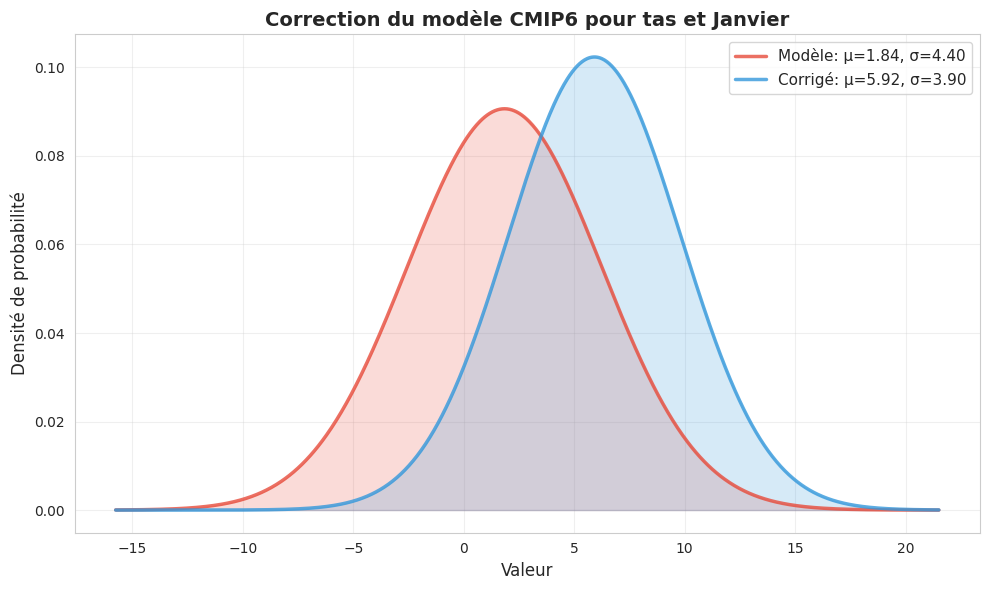

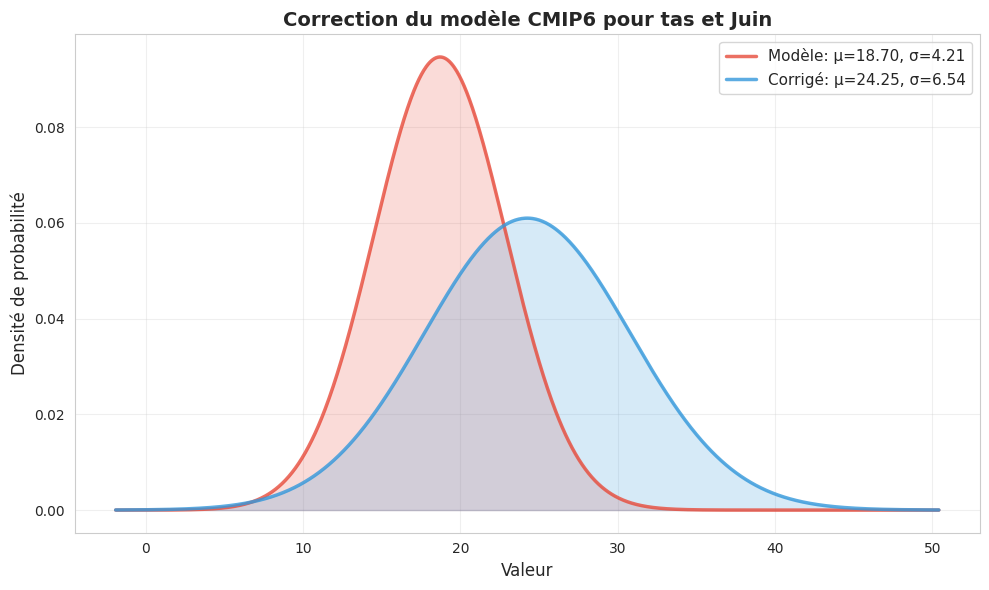

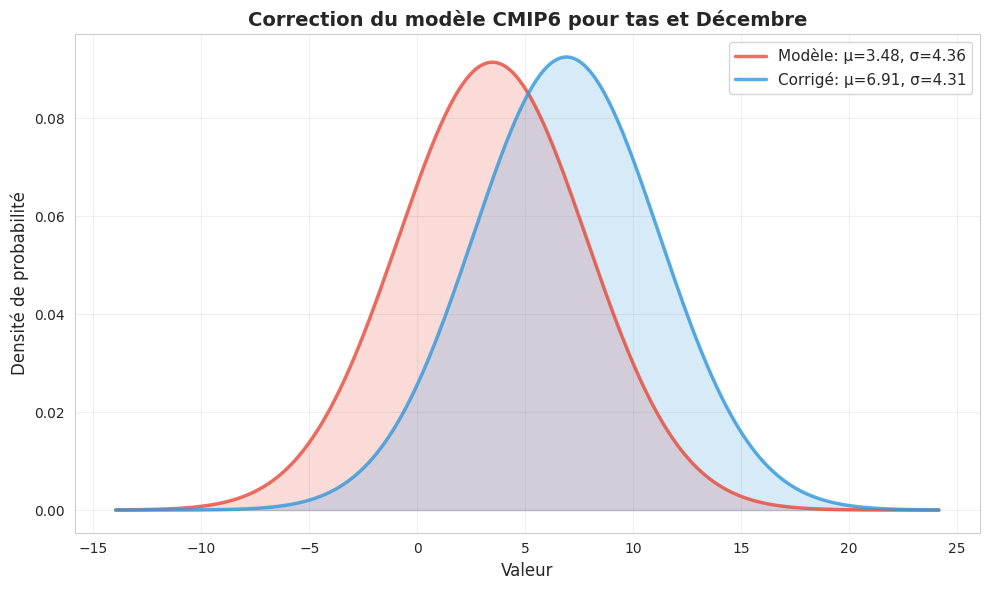

In [ ]:
mois_a_afficher = [6, 12]  

for i in range (1,13): #on itère sur tous les mois

    #Sélection mois et variable
    CMIP6_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_historical.csv", i, "tas")
    CMIP6_futur = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/CMIP6_ssp585.csv", i, "tas")
    obs_hist = csv_to_pd_univ("/home/onyxia/work/statapp_edf_25/data/obs.csv", i, "tas")

    #Correction des valeurs futures du modèle par CDF-t
    resultat = cdf_t_univ_norm(CMIP6_hist,obs_hist,CMIP6_futur)

    #Représentation graphique
    if i in mois_a_afficher:
        plot_distributions_univ_norm(resultat[0],resultat[1],"CMIP6", i, "tas")



## Implémentation CDF-t multivariée